In [1]:
import pdf2image  # PyMuPDF
import pytesseract
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import re
import json
import matplotlib.pyplot as plt

In [2]:
pytesseract.pytesseract.tesseract_cmd = r"C:/Program Files/Tesseract-OCR/tesseract.exe"

pdf_path = Path("normal_test.pdf")

doc = pdf2image.convert_from_path(pdf_path) #creates list object 

#width 1700, length 2200

pil_image = doc[0]
cv2_image = np.array(pil_image)


In [3]:
height, width, _ = cv2_image.shape

print (height, width)

2200 1700


In [ ]:
#FACILITY TYPE

type_start_point = (920, 330)
type_end_point = (1300, 480)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for type of facility
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 500 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.2  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")

            if is_filled:
                text_offset_x = 10  # pixels to skip after box
                text_width = 50    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

print (text)

#test

#probably can eliminate one instance of grayscaling


Checkbox at (16,110) - Filled: False, Fill Ratio: 0.10
Checkbox at (16,71) - Filled: False, Fill Ratio: 0.12
Checkbox at (16,33) - Filled: True, Fill Ratio: 0.25
Cou



In [ ]:
#FACILITY NAME

type_start_point = (270, 550)
type_end_point = (1100, 650)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

Macon County Jail



In [23]:
#TELEPHONE 

type_start_point = (1280, 550)
type_end_point = (1500, 650)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

217-424-1341



In [34]:
#Address - may need to break out?

type_start_point = (210, 660)
type_end_point = (1500, 700)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

333 s Franklin Decatur JIL 62522



In [41]:
#Date of Occurence

type_start_point = (340, 730)
type_end_point = (840, 800)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

01/06/2021



In [49]:
#Time of Occurence (numbers)

type_start_point = (1100, 730)
type_end_point = (1400, 800)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

1720



In [68]:
#Time of Occurence (AM/PM)

type_start_point = (1400, 730)
type_end_point = (1650, 800)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.5  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")

            if is_filled:
                text_offset_x = 5  # pixels to skip after box
                text_width = 40    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

print (text)

Checkbox at (124,27) - Filled: True, Fill Ratio: 0.52
Checkbox at (24,27) - Filled: False, Fill Ratio: 0.33
p.m.



In [ ]:
#Type of Occurence

type_start_point = (340, 825)
type_end_point = (1650, 1000)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

roi_width = x2 - x1
roi_height = y2 - y1

box_list = []
boxes = []

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            boxes.append((x,y))
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.3  # can adjust threashold
            #print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")
            if is_filled:
                text_offset_x = 5  # pixels to skip after box
                text_width = 80    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase
                box_list.append(text)
            else:
                if (x < roi_width*0.02 and y < roi_height*0.02) or (x > roi_width*0.7 and y < roi_height*0.02) or (x > roi_width*0.8 and y > roi_height*0.95):
                    text_offset_x = 5  # pixels to skip after box
                    text_width = 80    # width of text region to extract
                    text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                    text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                    _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                    text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase
                    if text == None or text in box_list:
                        pass
                    box_list.append(text)

print (box_list)

#(11,6)
#(635, 5)
#(859, 117)

#should just scan all of the possible coordinates

['Restrair\n']


In [159]:
boxes

[(10, 119),
 (634, 117),
 (409, 118),
 (859, 117),
 (409, 79),
 (160, 80),
 (10, 80),
 (858, 78),
 (634, 79),
 (160, 43),
 (11, 44),
 (634, 42),
 (409, 42),
 (1033, 41),
 (859, 42),
 (11, 6),
 (635, 5)]

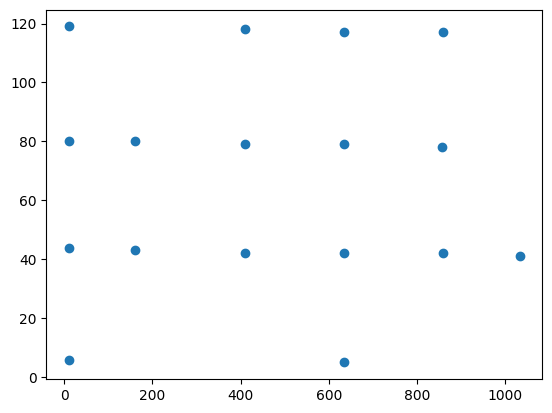

In [160]:
box_x = [box[0] for box in boxes]
box_y = [box[1] for box in boxes]

plt.scatter(box_x, box_y)

In [155]:
#Table

type_start_point = (100, 1000)
type_end_point = (1600, 1400)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 12')

#try to read by column - maybe split up by smaller rectangles?

#read first row, read second and see if there's a name: if not, append

stripped_text = text.strip().splitlines()
stripped_text = [s for s in stripped_text if s and s != "|"]
cells = stripped_text[5:]

multiples = [4,8,12,16]
for row in multiples:
    if len(cells) > row:
        if "|" in cells[row]:
            for extra_charge in cells[row:]:
                cells[row-1] += extra_charge
            cells = cells[:row]
        
print (cells)

['HARRIS, EROSHA K', '07/21/1997', '12/31/2020', 'METH MANUFACTURE/DEL| POSS AMT CON SUB| ILL POSS FIREARM/AMMO']


In [116]:
#Injuries

type_start_point = (300, 1380)
type_end_point = (1600, 1450)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for address
text = pytesseract.image_to_string(roi, config='--psm 6')

print (text)

XI] No (1 Yes, (briefly describe;



In [ ]:
#Resulting Death

type_start_point = (350, 1450)
type_end_point = (1600, 1530)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for dates
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 250 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.25  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")

            if is_filled:
                text_offset_x = 5  # pixels to skip after box
                text_width = 50    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase
    
    if text == "Yes":
        pass
        #insert processing for statements below

print (text)

Checkbox at (49,23) - Filled: True, Fill Ratio: 0.29
Checkbox at (150,23) - Filled: False, Fill Ratio: 0.09
No



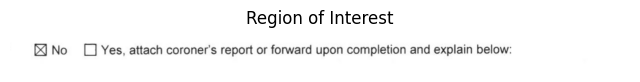

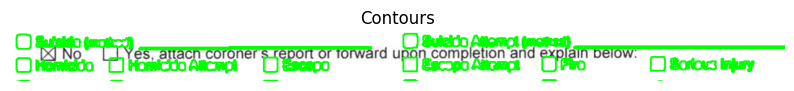

In [122]:
# Convert BGR to RGB for correct display with matplotlib
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
image_with_contours = roi.copy()
cv2.drawContours(image_with_contours, contours, -1, (0, 255, 0), 2)
image_with_contours_rgb = cv2.cvtColor(image_with_contours, cv2.COLOR_BGR2RGB)

# Display ROI
plt.figure(figsize=(8, 4))
plt.title("Region of Interest")
plt.imshow(roi_rgb)
plt.axis('off')
plt.show()

# Display contours
plt.figure(figsize=(10, 6))
plt.title("Contours")
plt.imshow(image_with_contours_rgb)
plt.axis('off')
plt.show()

In [123]:
text = pytesseract.image_to_string(roi, lang="eng", config="--psm 6")
print (text)

KI No [1 Yes, attach coroner's report or forward upon completion and explain below:



Notes:
- Need to turn page to black and white, contrast
- Need to break into smaller sections
- Identify four corners of the document on an angled document, do a coordinate projection
- Define regions for model to do dvisions
- Turn image into array, do conversions with color, blur slightly (cv2)
- Read cv2 functions - Canny could find boxes to fill in
- For boxes ---> Look at average value of pixels inside
- Every page should a row in a tabular dataset

Sections to break up:
- County/Municipal/Chicago PD *
- Faciltiy Name
- Telephone #
- Address
- Date
- Time *
- Type of Occurence *
- Detainees Table
- Any Injuries *
- Any resulting death? *
- Other death/injury data?